## Computer Vision
**What is Computer Vision?**

Computer Vision (CV) is the field of AI that lets machines **interpret and understand visual information** like images and videos.

**Applications:**
- Medical imaging: tumor detection, X-ray analysis
- Self-driving cars: lane detection, obstacle avoidance  
- Face recognition and authentication
- Google Lens, reverse image search
- Surveillance systems
- Quality control in manufacturing
- Image classification

### **Core Techniques**
1. Image Processing: 
    - Techniques for manipulating and enhancing digital images, including noise reduction, image transformations, and morphological operations 

2. Feature Extraction: 
    - Identifying distinctive elements in an image, such as **edges**, **corners**, and **textures**, which are crucial for analysis 

3. Deep Learning Models: 
    - Modern computer vision relies heavily on neural networks:
    
    1. **Convolutional Neural Networks (CNNs)**: Learn spatial hierarchies of features for tasks like image classification and object detection 
    
    2. Vision Transformers (ViT): Process images as sequences of patches using self-attention, often outperforming CNNs in certain tasks 
    
    3. Generative Models (GANs, VAEs): Generate realistic images or learn latent representations for complex visual tasks 
    
    4. Vision-Language Models: Integrate visual and textual information for tasks like image captioning and multimodal understanding 

### **Key Tasks**

1. **Image Classification**: Assigning a label to an image based on its content 

2. Object Detection: Identifying and locating objects within an image using bounding boxes 

3. Image Segmentation: Partitioning an image into regions to identify objects or boundaries at the pixel level 

4. Pose Estimation and OCR: Determining human body orientation or converting text in images into machine-readable formats

## **Convolutional Neural Networks**, 
- or CNNs, are a specialized class of neural networks designed to effectively process grid-like data
    - such as images
- Uses an operation called **Convolution** to process grid like data (images)
- They preserve spatial relationships 
- And learn from hierarchical features: Edge -> Shape -> Object
- 

[Introduction to Convolutional Neural Networks in Deep Learning](https://www.analyticsvidhya.com/blog/2022/03/basic-introduction-to-convolutional-neural-network-in-deep-learning)

![](https://editor.analyticsvidhya.com/uploads/94787Convolutional-Neural-Network.jpeg)

It is made up of multiple layers, including convolutional layers, pooling layers, and fully connected layers to automatically detect spatial hierarchies in the data (e.g., edges, textures, and patterns).

![](https://miro.medium.com/freeze/max/661/1*sCUNjAOQvXc3dr8dcSSfoA.gif)

- **Convolutional Layers**
    - These layers apply convolutional operations to input images, using filters (also known as kernels) of a specific size *M x M*
    - Detect features such as edges, textures, and more complex patterns 
    - Convolutional operations help preserve the spatial relationships between pixels 


- **Pooling Layers**
    - These layers downsample the spatial dimensions of the input, reducing the computational complexity and the number of parameters in the network
    - **Max Pooling** is a common pooling operation, **selecting the maximum value** from a group of neighboring pixels
    - **Average Pooling** calculates the total sum of components in a predefined section

- **Dropout**
    - To avoid overfitting, this layer removes a few neurons from the neural network during training
    - results in a smaller model


Some of the layers in a CNN:
- Conv2D:
    - It applies learnable filters (kernels) to an input image (or feature map) to extract spatial features such as edges, textures, and patterns
    ![](https://media.geeksforgeeks.org/wp-content/uploads/20230216175224/how-to-apply-a-2d-convolution-operation-in-pytorch.gif)
    - [Conv2D](https://www.geeksforgeeks.org/computer-vision/apply-a-2d-convolution-operation-in-pytorch/)

- MaxPool2D:
    - MaxPool2D is a pooling operation used in convolutional neural networks (CNNs) to downsample spatial dimensions (height and width) of feature maps while retaining the most important features. 
    ![](https://miro.medium.com/v2/resize:fit:1100/format:webp/1*gaD6SJ6kQNVOclE_WkwLNQ.png)
    - 

- Let's build something and learn along the way
- **Handwritten Digit Recognition System**

In [84]:
import warnings
warnings.filterwarnings('ignore')

In [85]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf

In [86]:
# get the data
data = tf.keras.datasets.mnist.load_data()
type(data)
len(data[0])

(X_train, y_train), (X_test, y_test) = data

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  13  25 100 122   7   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0  33 151 208 252 252 252 146   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  40 152 244 252 253 224 211 252 232  40   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0  15 152 239 252 252 252 216  31  37 252 25

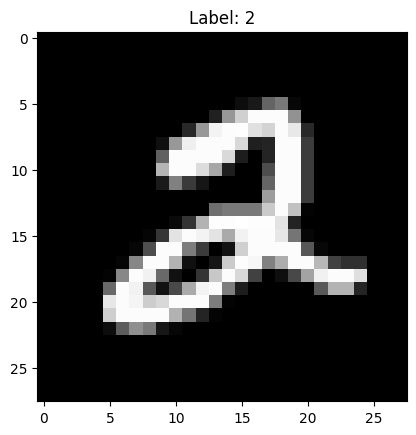

In [87]:
data[0] # shape=(60000, 28, 28) --- Training set (X_train, y_train)
data[1] # shape=(10000, 28, 28) --- Testing set (X_test, y_test)

len(data[0][0]) # 60000 --- Images - every one is 28 x 28 --- X_train
len(data[0][1]) # 60000 --- Labels - you have a digit as well --- y_train
# 60K images, 2D images

# np.set_printoptions(linewidth=150)
print(data[0][0][5]) # zeroth image

plt.imshow(X_train[5], cmap = 'grey')
plt.title(f"Label: {y_train[5]}")
plt.show()

In [88]:
X_train[5].shape
len(X_train[0].flatten())

# np.unique(y_train)

784

- images are just numbers stored in arrays
- 2D with 1 channel - Gray scale image
- 3D with 3 channels - R G B
- 
- grayscale image matrix ===> (28, 28, 1)
- Color images ===> (28, 28, 3) (height, width, channels)

In [89]:
# Modeling
from tensorflow.keras import layers

DL_model = tf.keras.models.Sequential([
    # input layer
    layers.Flatten(input_shape = (28, 28)), # squishes the 2D array into a 1D array
    layers.Dense(128, activation= 'relu'),
    layers.Dense(10, activation ='softmax') # loudest voice

])

DL_model.compile(optimizer= 'adam', loss = 'sparse_categorical_crossentropy', metrics=['accuracy'])

DL_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [90]:
# Train and Evaluate
DL_model.fit(X_train, y_train, epochs = 3, batch_size = 10)

test_loss, test_acc = DL_model.evaluate(X_test, y_test)

Epoch 1/3
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 0.8377 - loss: 1.7977
Epoch 2/3
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.9036 - loss: 0.4044
Epoch 3/3
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 0.9180 - loss: 0.3567
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9261 - loss: 0.3526


In [91]:
print(f"Test accuracy of the model is: {test_acc*100:.2f}% ")

Test accuracy of the model is: 92.61% 


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


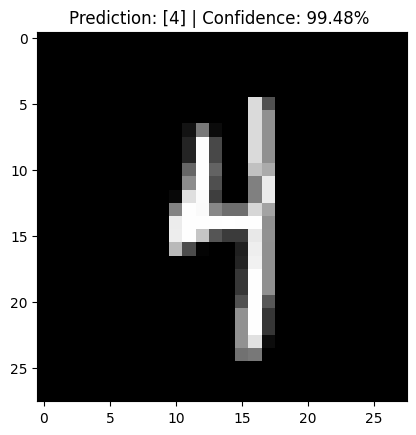

In [115]:
# make an arbitrary prediction

img = X_test[65]

prediction_img = DL_model.predict(img.reshape(1, 28, 28))
                                  
prediction_label = np.argmax(prediction_img, axis = 1)
confidence = prediction_img[0][prediction_label]


plt.imshow(img, cmap= 'gray')
plt.title(f"Prediction: {prediction_label} | Confidence: {float(confidence)*100:.2f}% ")
plt.show()

In [ ]:
prediction_img[0][prediction_label]

array([0.9879], dtype=float32)

In [94]:
img = X_test[10]

img.reshape(1, 28, 28).shape

# np.expand_dims(img, 0).shape

(1, 28, 28)